In [179]:
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [180]:
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
numeric_clinical = clinical_df.select_dtypes(include=['number']).columns

features_df = pd.read_csv(r"D:\CSV\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
# features_df = pd.read_csv(r"D:\CSV\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
numeric_features = features_df.select_dtypes(include=['number']).columns

CORRELATION BETWEEN CLINICAL DATA AND IMAGE FEATURES

In [181]:
scaler = StandardScaler()

clinical_scaled = pd.DataFrame(scaler.fit_transform(clinical_df[numeric_clinical]),
                               columns=clinical_df[numeric_clinical].columns,
                               index=clinical_df[numeric_clinical].index)

features_scaled = pd.DataFrame(scaler.fit_transform(features_df[numeric_features]),
                               columns=features_df[numeric_features].columns,
                               index=features_df[numeric_features].index)

In [182]:
clinical_column = 'Beta2 microglobulin (mg/l)'

spearman_corr = {}

for col in features_scaled[numeric_features].columns:
    valid_idx = features_scaled[col].notna() & clinical_scaled[clinical_column].notna()
    corr, p_value = spearmanr(features_scaled[col][valid_idx], clinical_scaled[clinical_column][valid_idx])
    spearman_corr[col] = {'spearman_corr': corr, 'p_value': p_value}

spearman_df = pd.DataFrame(spearman_corr).T
spearman_df = spearman_df.sort_values(by='spearman_corr', ascending=False)

# pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')
spearman_df

,spearman_corr,p_value
original_glcm_Idm,0.505298,0.000010
original_glcm_Id,0.504476,0.000010
gradient_gldm_LowGrayLevelEmphasis,0.498429,0.000013
gradient_glrlm_LongRunLowGrayLevelEmphasis,0.486518,0.000022
gradient_glrlm_LowGrayLevelRunEmphasis,0.485951,0.000023
...,...,...
original_glrlm_RunLengthNonUniformityNormalized,-0.476945,0.000034
original_glcm_DifferenceEntropy,-0.477913,0.000033
original_glrlm_ShortRunEmphasis,-0.478571,0.000032
original_glcm_DifferenceAverage,-0.482882,0.000026


BOXPLOT FOR STAGE AND SELECTED IMAGE FEATURES

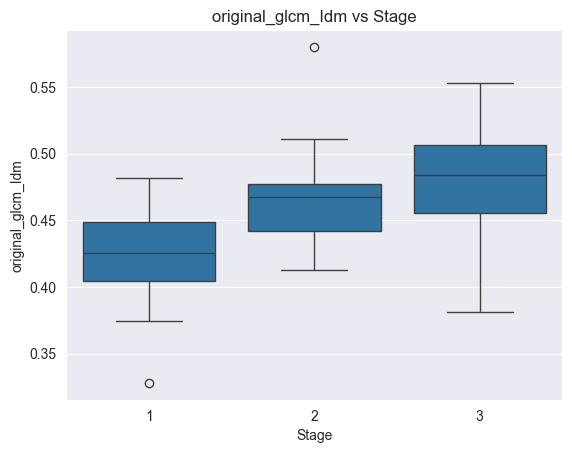

In [183]:
pd.set_option('future.no_silent_downcasting', True)
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

img_feature = "original_glcm_Idm"  # original_firstorder_Range -> useless

data = pd.concat([features_df[img_feature], clinical_df['Stage']], axis=1).dropna()
sns.boxplot(x='Stage', y=img_feature, data=data)
plt.xlabel('Stage')
plt.ylabel(img_feature)
plt.title(f'{img_feature} vs Stage')
plt.show()

In [184]:
from sklearn.linear_model import Lasso

valid_idx = clinical_scaled['Beta2 microglobulin (mg/l)'].notna()

lasso = Lasso(alpha=0.01)
X = features_scaled[numeric_features][valid_idx]
y = clinical_scaled['Beta2 microglobulin (mg/l)'][valid_idx]
lasso.fit(X, y)

print("R^2 score Lasso:", lasso.score(X, y))
feature_weights = pd.Series(lasso.coef_, index=X.columns)
feature_weights

R^2 score Lasso: 0.8317476996272839


n_lesions                        -0.485925
original_shape_Elongation        -0.000000
original_shape_Flatness          -0.000000
original_shape_LeastAxisLength    0.179611
original_shape_MajorAxisLength    1.022180
                                    ...   
gradient_ngtdm_Busyness           0.000000
gradient_ngtdm_Coarseness        -0.013310
gradient_ngtdm_Complexity        -0.000000
gradient_ngtdm_Contrast          -0.000000
gradient_ngtdm_Strength          -0.000000
Length: 201, dtype: float64

In [185]:
combined_feature = X.dot(feature_weights)
corr, p_value = spearmanr(combined_feature, y)
print(f"Spearmanova korelácia kombinovaného príznaku: {corr:.3f}")
print(f"P-hodnota: {p_value:.3e}")

Spearmanova korelácia kombinovaného príznaku: 0.750
P-hodnota: 1.154e-13
